# 📊 Exploratory Data Analysis (EDA) for MCI Deployment Feasibility

This notebook explores the MCI Index dataset for scoring country-wise readiness and sustainability for Pretups deployment. We visualize key metrics, clusters, and patterns in the dataset.


## 🧰 Importing Required Libraries

We'll use Pandas, Seaborn, and Matplotlib for data exploration and visualization.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## 📥 Load the Processed MCI Dataset

We load the scored MCI dataset generated after preprocessing, clustering, and scoring.


In [10]:
import pandas as pd

# Corrected path based on notebook location
df = pd.read_csv("../data/processed/scored_mci.csv")
df.head()


,ISO Code,Country,Region,Year,Cluster,Index,Infrastructure,Affordability,Consumer Readiness,Content and Services,...,Top-Level Domains (TLDs) per person,E-Government Score,Mobile Social Media Penetration,Locally developed apps per person,Digital Language Support,Language accessibility of top ranked apps,Cybersecurity Index,Readiness Score,Sustainability Score,Potential Deployment
0,AFG,Afghanistan,South Asia,2021,1,25.98,36.74,22.05,22.41,25.08,...,39.76,34.44,10.18,44.92,38.19,0.00,5.20,70,75,Yes
1,AFG,Afghanistan,South Asia,2022,1,27.28,39.59,25.47,22.83,24.05,...,39.39,27.70,7.56,43.34,39.68,0.00,5.20,70,75,Yes
2,AFG,Afghanistan,South Asia,2023,1,29.62,41.59,28.43,26.86,24.22,...,38.90,27.70,8.64,42.16,41.33,0.00,5.20,70,75,Yes
3,AFG,Afghanistan,South Asia,2024,1,26.71,45.71,18.96,23.68,24.81,...,38.28,14.38,9.22,35.70,41.63,0.00,18.42,70,75,Yes
4,AGO,Angola,Sub-Saharan Africa,2021,1,43.99,47.63,52.65,50.04,29.85,...,16.21,47.99,7.72,47.27,45.93,58.45,12.99,70,75,Yes


## 📋 Dataset Overview

Let's check the shape, column names, and a few sample rows.


In [11]:
print("Shape of dataset:", df.shape)
print("\nColumn Names:", df.columns.tolist())
df.head()


Shape of dataset: (690, 56)

Column Names: ['ISO Code', 'Country', 'Region', 'Year', 'Cluster', 'Index', 'Infrastructure', 'Affordability', 'Consumer Readiness', 'Content and Services', 'Network coverage', 'Network performance', 'Spectrum', 'Mobile data affordability', 'Handset affordability', 'Taxation', 'Mobile Ownership', 'Basic Skills', 'Gender Equality', 'Local Relevance', 'Online Security', '2G Population Coverage', '3G Population Coverage', '4G Population Coverage', '5G Population Coverage', 'Mobile download speeds', 'Mobile upload speeds', 'Mobile latencies', 'Spectrum assigned in bands below 1GHz', 'Spectrum assigned in bands between 1-3GHz', 'Spectrum assigned in bands between 3-6GHz', 'Spectrum assigned in mmWave bands', 'Affordability of entry basket (1GB)', 'Affordability of higher basket (5GB)', 'Affordability of entry basket (1GB) for poorest 40%', 'Affordability of higher basket (5GB) for poorest 40%', 'Device affordability', 'Device affordability for poorest 40%', 'Cos

,ISO Code,Country,Region,Year,Cluster,Index,Infrastructure,Affordability,Consumer Readiness,Content and Services,...,Top-Level Domains (TLDs) per person,E-Government Score,Mobile Social Media Penetration,Locally developed apps per person,Digital Language Support,Language accessibility of top ranked apps,Cybersecurity Index,Readiness Score,Sustainability Score,Potential Deployment
0,AFG,Afghanistan,South Asia,2021,1,25.98,36.74,22.05,22.41,25.08,...,39.76,34.44,10.18,44.92,38.19,0.00,5.20,70,75,Yes
1,AFG,Afghanistan,South Asia,2022,1,27.28,39.59,25.47,22.83,24.05,...,39.39,27.70,7.56,43.34,39.68,0.00,5.20,70,75,Yes
2,AFG,Afghanistan,South Asia,2023,1,29.62,41.59,28.43,26.86,24.22,...,38.90,27.70,8.64,42.16,41.33,0.00,5.20,70,75,Yes
3,AFG,Afghanistan,South Asia,2024,1,26.71,45.71,18.96,23.68,24.81,...,38.28,14.38,9.22,35.70,41.63,0.00,18.42,70,75,Yes
4,AGO,Angola,Sub-Saharan Africa,2021,1,43.99,47.63,52.65,50.04,29.85,...,16.21,47.99,7.72,47.27,45.93,58.45,12.99,70,75,Yes


## 📈 Descriptive Statistics

We explore the overall distribution of values in each numerical column.


In [12]:
df.describe()


,Year,Cluster,Index,Infrastructure,Affordability,Consumer Readiness,Content and Services,Network coverage,Network performance,Spectrum,...,Gender gap in mobile internet,Top-Level Domains (TLDs) per person,E-Government Score,Mobile Social Media Penetration,Locally developed apps per person,Digital Language Support,Language accessibility of top ranked apps,Cybersecurity Index,Readiness Score,Sustainability Score
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,...,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,2022.495652,1.481159,63.443899,66.985928,58.306565,72.025232,59.604174,85.150348,57.516087,49.597029,...,75.326377,54.714594,59.267174,52.601928,71.669884,57.239043,63.587449,59.899406,66.710145,68.956522
std,1.117539,1.137981,19.154420,16.319827,21.307130,19.842551,21.752015,13.571365,21.142237,22.889990,...,31.245695,22.556796,23.913087,27.520855,20.558158,30.609324,30.183793,33.419723,16.735890,13.100521
min,2021.000000,0.000000,10.520000,14.560000,3.450000,15.720000,7.830000,21.600000,3.230000,8.300000,...,0.000000,0.000000,2.300000,1.730000,12.100000,3.010000,0.000000,0.000000,45.000000,50.000000
25%,2021.250000,0.000000,49.805000,56.175000,43.955000,60.317500,42.047500,81.562500,41.515000,31.520000,...,59.685000,37.192500,39.722500,26.085000,58.102500,28.250000,39.525000,27.740000,60.000000,65.000000
50%,2022.000000,2.000000,64.890000,64.935000,58.590000,79.240000,60.095000,88.200000,53.835000,42.810000,...,91.110000,54.555000,60.890000,60.905000,73.785000,60.410000,70.040000,68.460000,60.000000,65.000000
75%,2023.000000,2.000000,80.297500,80.127500,76.150000,87.400000,79.542500,95.240000,71.072500,70.970000,...,100.000000,72.687500,79.852500,74.192500,87.702500,84.277500,91.000000,92.595000,90.000000,85.000000
max,2024.000000,3.000000,93.280000,98.830000,100.000000,96.240000,94.400000,100.000000,98.180000,99.380000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,90.000000,85.000000


## 🌍 Top Countries by Readiness and Sustainability

We now visualize the top 20 countries based on:
- Readiness Score (economic, language, connectivity factors)
- Sustainability Score (long-term viability of a Pretups deployment)


### 🔝 Top 20 Countries by Readiness Score


/var/folders/8y/3qjztzs97911rrlc6z42czw80000gn/T/ipykernel_36398/3675529381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_readiness, x="Readiness Score", y="Country", palette="Blues_d")


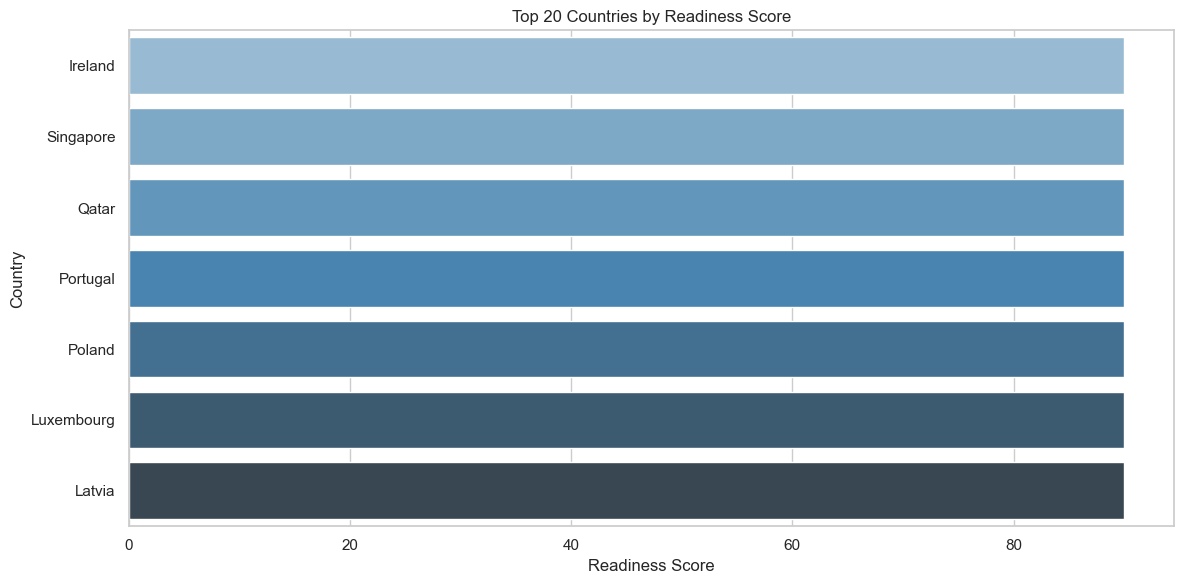

In [13]:
top_readiness = df.sort_values(by="Readiness Score", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_readiness, x="Readiness Score", y="Country", palette="Blues_d")
plt.title("Top 20 Countries by Readiness Score")
plt.tight_layout()
plt.show()


### 🌱 Top 20 Countries by Sustainability Score


/var/folders/8y/3qjztzs97911rrlc6z42czw80000gn/T/ipykernel_36398/3841243168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sustain, x="Sustainability Score", y="Country", palette="Greens_d")


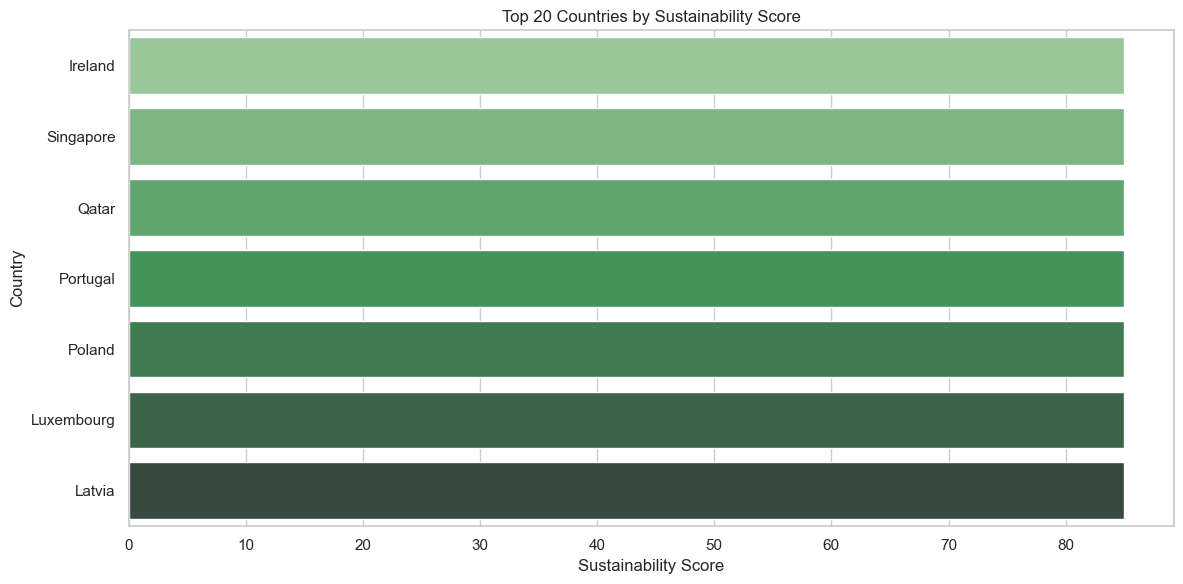

In [14]:
top_sustain = df.sort_values(by="Sustainability Score", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_sustain, x="Sustainability Score", y="Country", palette="Greens_d")
plt.title("Top 20 Countries by Sustainability Score")
plt.tight_layout()
plt.show()


## 📦 Clustering Distribution

How many countries fall into each cluster? We visualize that using a countplot.


/var/folders/8y/3qjztzs97911rrlc6z42czw80000gn/T/ipykernel_36398/1450623745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Cluster", palette="Set2")


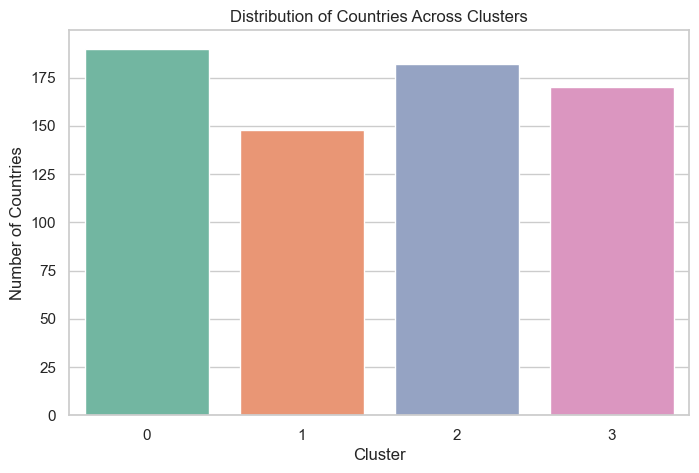

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Cluster", palette="Set2")
plt.title("Distribution of Countries Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")
plt.show()


## 🧠 Feature Correlation Heatmap

This heatmap helps understand which indicators are most correlated with readiness or sustainability.


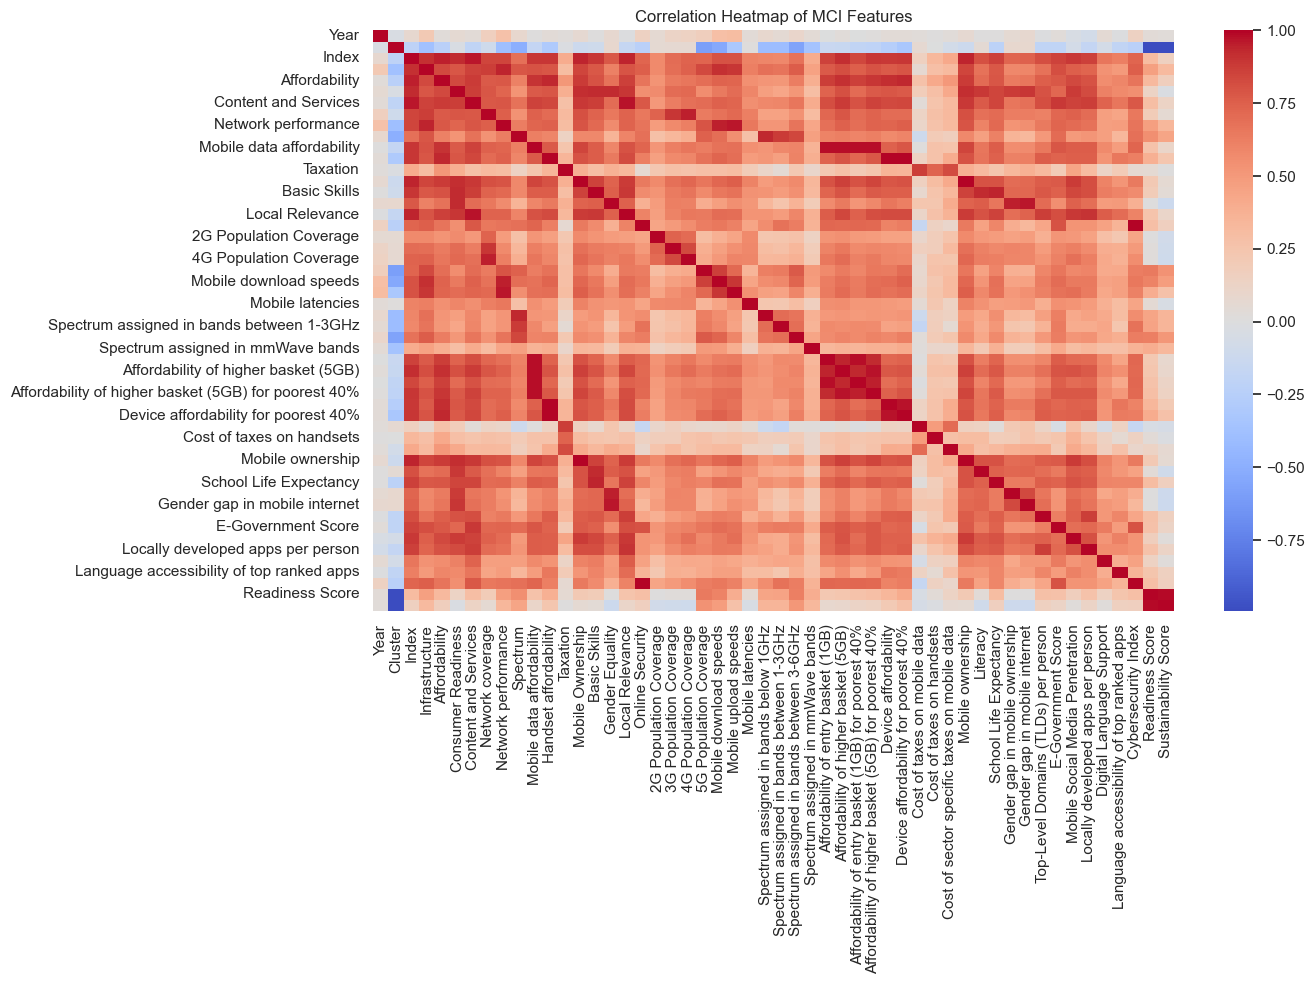

In [16]:
# Selecting only numerical columns
num_df = df.select_dtypes(include="number")

plt.figure(figsize=(14, 10))
sns.heatmap(num_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of MCI Features")
plt.tight_layout()
plt.show()


## ✅ Summary

This EDA notebook helped us:
- Understand the MCI dataset structure
- Explore key indicators of readiness and sustainability
- Visualize cluster distribution for strategic planning

### Next Steps:
- Use these insights in the Streamlit dashboard
- Focus deployment decisions on high-scoring countries in viable clusters
